In [ ]:
import requests
import geopandas as gpd

## Input data

In [ ]:
local_crs = 32636

Get the MO polygons

In [9]:
polygons = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/lo_gdfs/polygons188.geojson').to_crs(local_crs)

Get the project territory

In [ ]:
terr_context_request = requests.get('http://10.32.1.107:5300/api/v1/projects/73')

Get settlement points

In [3]:
def fetch_territories(
    url='https://urban-api.testing.idulab.ru/api/v1/all_territories',
    parent_id=1,
    get_all_levels=True,
    territory_type_id=None,
    name=None,
    cities_only=True,
    created_at=None,
    centers_only=True
):
    params = {
        'parent_id': parent_id,
        'get_all_levels': get_all_levels,
        'territory_type_id': territory_type_id,
        'name': name,
        'cities_only': cities_only,
        'created_at': created_at,
        'centers_only': centers_only
    }
   
    response = requests.get(url, params=params)
    
    return gpd.GeoDataFrame.from_features(response.json()['features']).set_crs(epsg=4326)

settlement_points = fetch_territories("http://10.32.1.107:5300/api/v1/all_territories",1)

Get the context polygons

In [4]:
from shapely.geometry import shape
str_indx = [str(idx) for idx in terr_context_request.json()['properties']['context']]
request_str = '%2C'.join(str_indx)
context = requests.get(f'http://10.32.1.107:5300/api/v1/territories/{request_str}?centers_only=false')
context_features = context.json()['features']
geoms = []
props = []

for feature in context_features:
    geoms.append(shape(feature['geometry']))
    props.append(feature.get('properties', {}))  # могут быть пустыми

context = gpd.GeoDataFrame(props, geometry=geoms, crs="EPSG:4326")


Get the adjacency matrix between the settlement points

In [ ]:
import pickle
with open('/Users/polina/Downloads/TRNDP/Transit_Planner/examples/experiments/1_car_matrix.pickle','rb') as f:
    adj_mx = pickle.load(f)

## Method

In [11]:
from transport_frames.context_availability import get_context_connectivity

con = get_context_connectivity(settlement_points,context,adj_mx,polygons,local_crs)


/Users/polina/Desktop/tf2/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


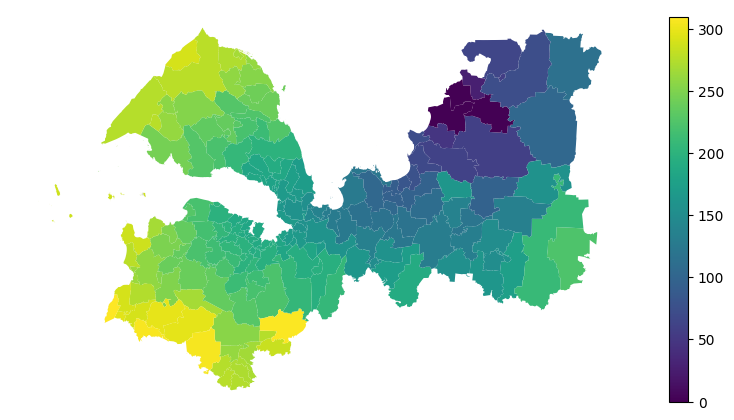

In [12]:
import matplotlib.pyplot as plt

fin_webm  = con.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 10))
fin_webm.plot(
    column="median_connectivity",
    legend=True,
    legend_kwds={'shrink':0.5},
    ax=ax,
)

ax.set_axis_off()
plt.show()
